# Localized vs Non-Localized Domain Analysis
### Google Health Search · 4 Countries · `data/all_google.csv`

This notebook analyzes whether the domains cited in Google AI Overviews are **localized** (using the country's own top-level domain) or **non-localized** (global/US-centric domains).

**Localization rules:**

| Country | Localized TLDs |
|---|---|
| Australia | `.au` (`.com.au`, `.gov.au`, `.org.au`, `.edu.au`, `.net.au`) |
| India | `.in` (`.co.in`, `.gov.in`, `.org.in`, `.net.in`) |
| United Kingdom | `.uk` (`.co.uk`, `.nhs.uk`, `.org.uk`, `.gov.uk`, `.ac.uk`) and `.scot` |
| United States | `.gov` and `.edu` — de-facto US-only TLDs used as a proxy, since `.us` is rarely used in practice |

> **Note on US methodology:** Because the `.us` ccTLD is seldom used, `.gov` and `.edu` serve as the best available proxies for US-localized government and academic health sources.

In [1]:
import ast
import pandas as pd
from urllib.parse import urlparse
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8fafc",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "axes.grid.axis": "x",
    "grid.color": "#e2e8f0",
    "grid.linewidth": 0.8,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ── Palette ───────────────────────────────────────────────────────────────────
COUNTRY_COLORS = {
    "United States":  "#1565c0",
    "United Kingdom": "#2e7d32",
    "Australia":      "#e65100",
    "India":          "#6a1b9a",
}
LOC_COLOR   = "#1976d2"   # localized
NONLOC_COLOR = "#b0bec5"  # non-localized
SECTION_COLORS = ["#1565c0", "#42a5f5", "#80cbc4", "#a5d6a7"]

print("Libraries loaded.")

Libraries loaded.


## 1 · Load Data & Extract Domains

In [2]:
df = pd.read_csv("data/all_google.csv")

# Parse all_references safely
def parse_refs(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

df["refs_parsed"] = df["all_references"].apply(parse_refs)

# Extract (domain, full_url) pairs per row
def extract_domains(refs):
    domains = []
    for ref in refs:
        url = ref.get("link", "")
        if url:
            netloc = urlparse(url).netloc.lower().lstrip("www.")
            domains.append(netloc)
    return domains

df["domains"] = df["refs_parsed"].apply(extract_domains)

print(f"Rows: {len(df)}")
print(f"Countries: {sorted(df['location'].unique())}")
print(f"Total domain mentions: {df['domains'].apply(len).sum():,}")

Rows: 478
Countries: ['Australia', 'India', 'United Kingdom', 'United States']
Total domain mentions: 4,080


In [3]:
# ── Localization classifier ───────────────────────────────────────────────────
LOCALIZED_TLDS = {
    "Australia":      (".au",),
    "India":          (".in",),
    "United Kingdom": (".uk", ".scot"),
    # .gov and .edu are de-facto US-only TLDs
    "United States":  (".gov", ".edu"),
}

def is_localized(domain: str, country: str) -> bool:
    suffixes = LOCALIZED_TLDS.get(country, ())
    return any(domain == s.lstrip(".") or domain.endswith(s) for s in suffixes)

# Build a flat table: one row per (query_row, domain)
records = []
for _, row in df.iterrows():
    country = row["location"]
    section = row["section"] if pd.notna(row["section"]) else "unknown"
    has_ai  = str(row["has_ai_overview"]).strip().lower() == "true"
    for domain in row["domains"]:
        records.append({
            "country":      country,
            "section":      section,
            "has_ai":       has_ai,
            "domain":       domain,
            "localized":    is_localized(domain, country),
        })

flat = pd.DataFrame(records)
print(f"Domain-level rows: {len(flat):,}")
flat.head()

Domain-level rows: 4,080


,country,section,has_ai,domain,localized
0,United States,common_conditions,True,mayoclinic.org,False
1,United States,common_conditions,True,ho.int,False
2,United States,common_conditions,True,cancer.org,False
3,United States,common_conditions,True,cdc.gov,True
4,United States,common_conditions,True,cancer.gov,True


## 2 · Overall Localization Rate by Country

In [4]:
summary = (
    flat.groupby(["country", "localized"])
        .size()
        .rename("count")
        .reset_index()
)
summary["pct"] = summary.groupby("country")["count"].transform(lambda x: x / x.sum() * 100)

pivot = summary.pivot(index="country", columns="localized", values=["count", "pct"]).fillna(0)
pivot.columns = ["non_loc_count", "loc_count", "non_loc_pct", "loc_pct"]
pivot = pivot.sort_values("loc_pct", ascending=False)
pivot["total"] = pivot["loc_count"] + pivot["non_loc_count"]
pivot[["loc_count", "non_loc_count", "total", "loc_pct", "non_loc_pct"]].astype({"loc_count": int, "non_loc_count": int, "total": int}).round(1)

,loc_count,non_loc_count,total,loc_pct,non_loc_pct
country,,,,,
Australia,520,558,1078,48.2,51.8
United Kingdom,426,606,1032,41.3,58.7
United States,227,771,998,22.7,77.3
India,22,950,972,2.3,97.7


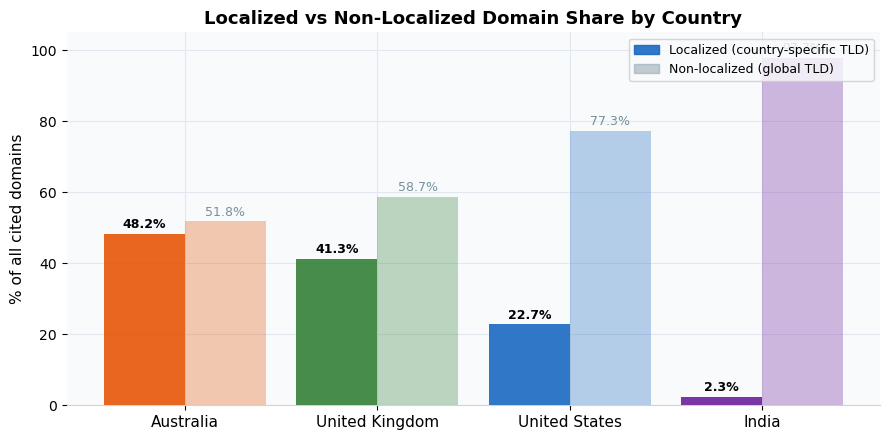

In [5]:
countries = pivot.index.tolist()
loc_pcts   = pivot["loc_pct"].values
nonloc_pcts = pivot["non_loc_pct"].values
bar_colors = [COUNTRY_COLORS[c] for c in countries]

fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(countries))
w = 0.42

b1 = ax.bar(x - w/2, loc_pcts,   width=w, color=bar_colors, label="Localized",     alpha=0.88, zorder=3)
b2 = ax.bar(x + w/2, nonloc_pcts, width=w, color=bar_colors, label="Non-localized", alpha=0.30, zorder=3)

# Value labels
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9, color="#78909c")

ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=11)
ax.set_ylabel("% of all cited domains")
ax.set_title("Localized vs Non-Localized Domain Share by Country")
ax.set_ylim(0, 105)
ax.grid(axis="y", color="#e2e8f0")
ax.set_axisbelow(True)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#cbd5e1")

loc_patch    = mpatches.Patch(color="#1565c0", alpha=0.88, label="Localized (country-specific TLD)")
nonloc_patch = mpatches.Patch(color="#90a4ae", alpha=0.55, label="Non-localized (global TLD)")
ax.legend(handles=[loc_patch, nonloc_patch], loc="upper right", fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig("localized_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Per-Country Deep Dive: Top Localized & Non-Localized Domains

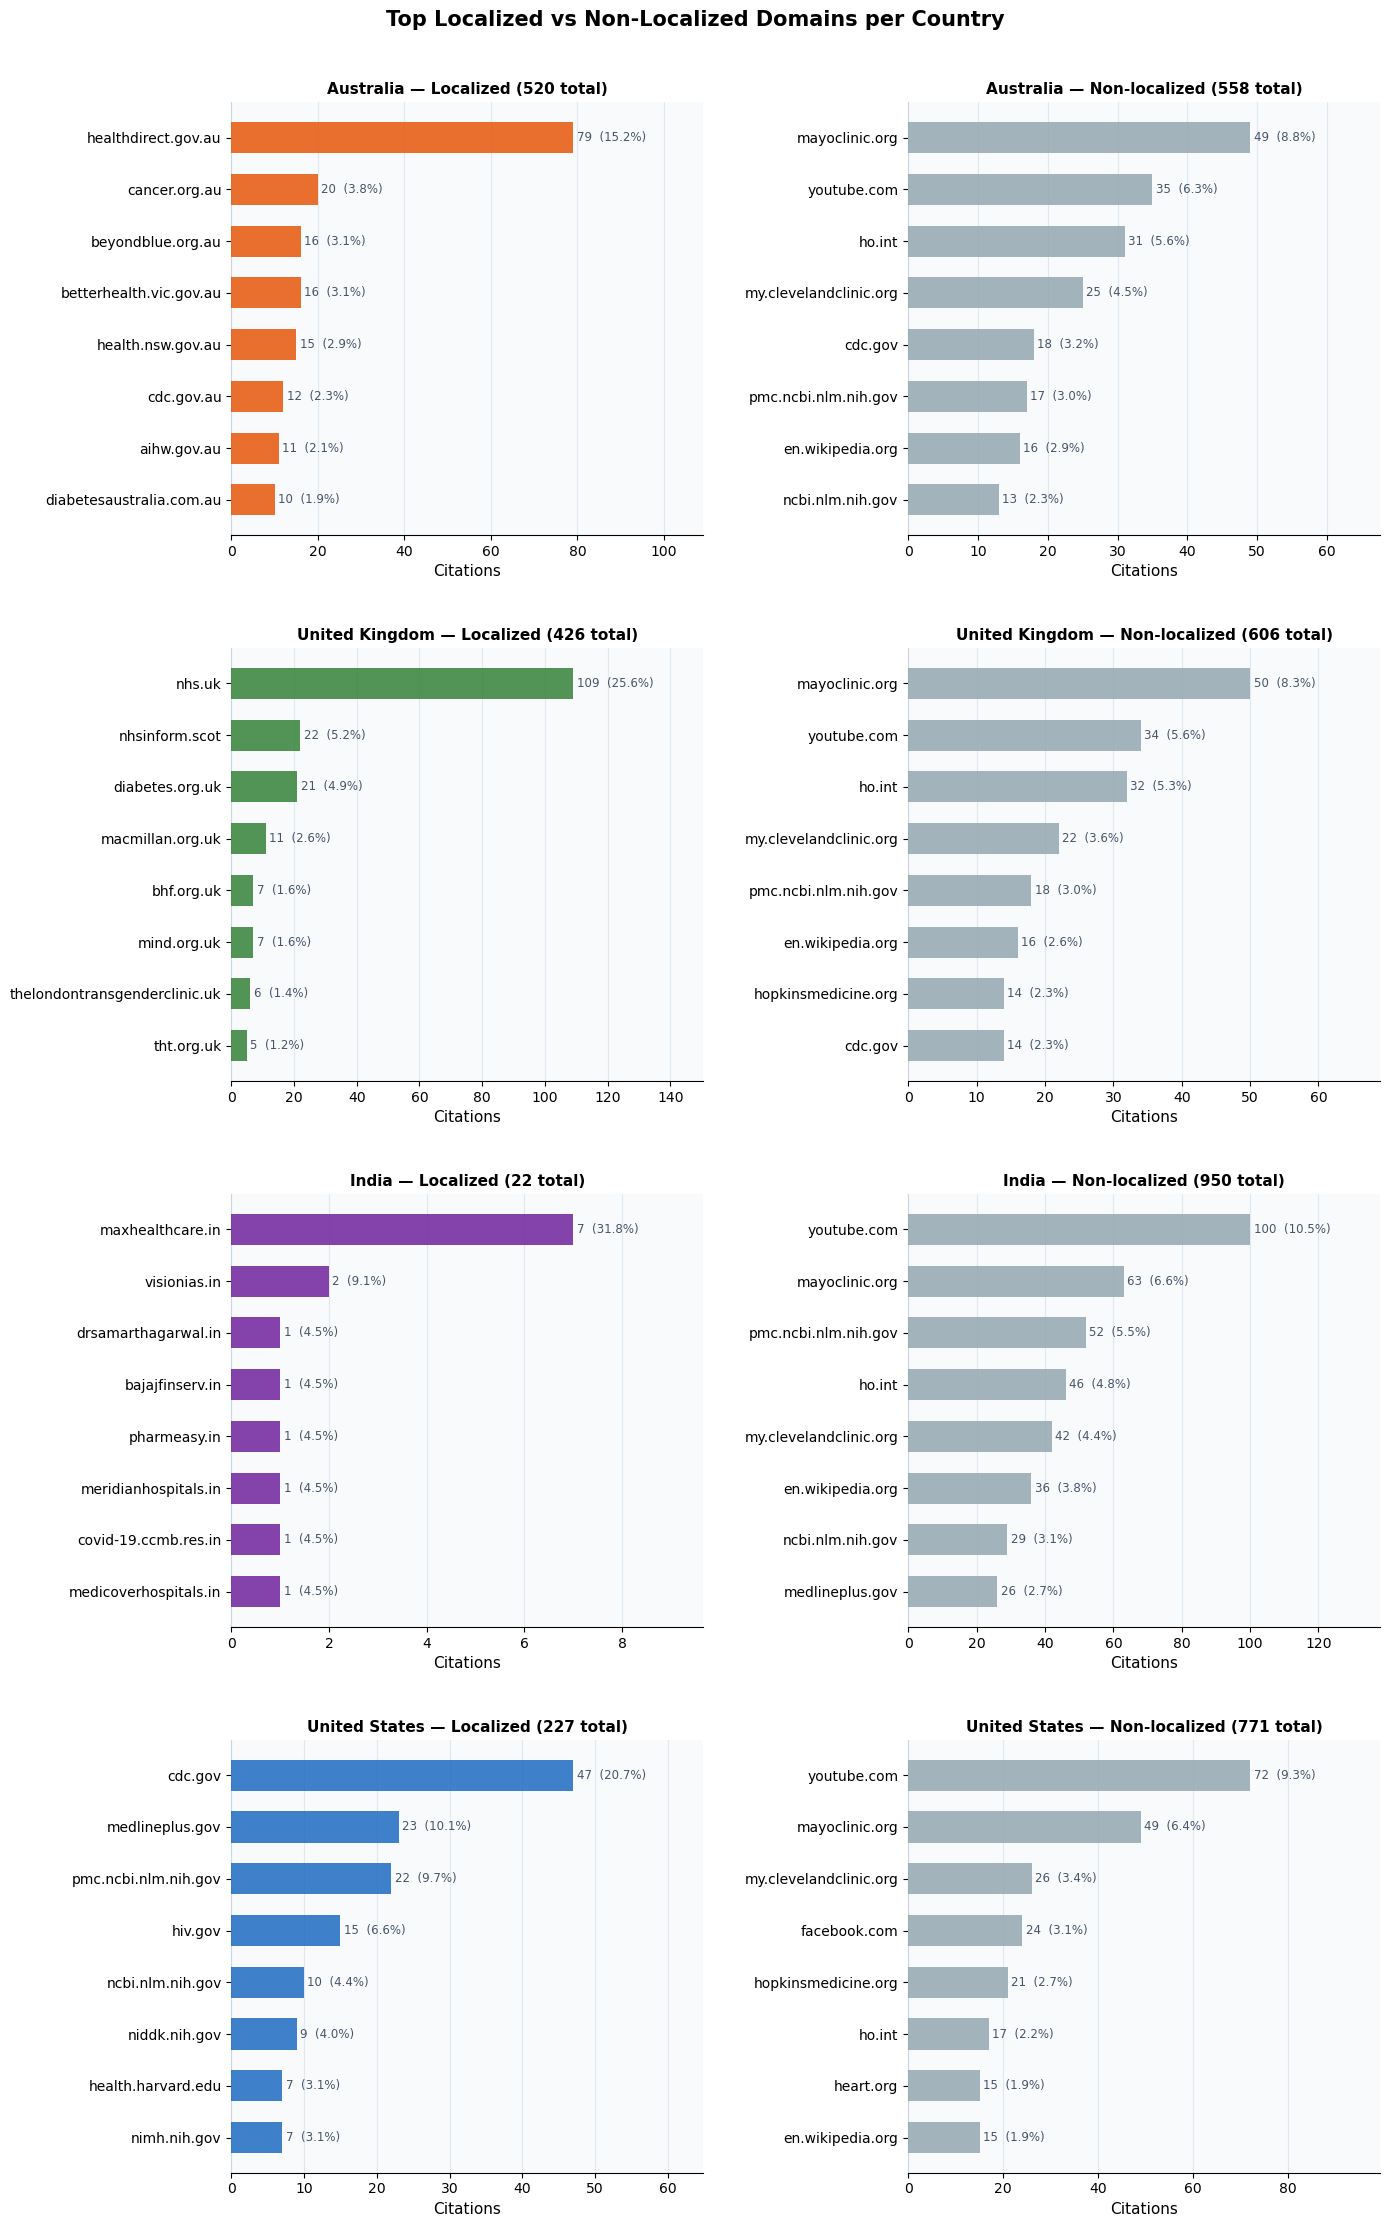

In [6]:
COUNTRY_ORDER = ["Australia", "United Kingdom", "India", "United States"]
TOP_N = 8

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.suptitle("Top Localized vs Non-Localized Domains per Country", fontsize=15, fontweight="bold", y=1.01)

for row_i, country in enumerate(COUNTRY_ORDER):
    cdf = flat[flat["country"] == country]
    color = COUNTRY_COLORS[country]

    for col_i, (is_loc, label, col_color) in enumerate([
        (True,  "Localized",     color),
        (False, "Non-localized", "#90a4ae"),
    ]):
        ax = axes[row_i][col_i]
        top = (cdf[cdf["localized"] == is_loc]["domain"]
               .value_counts()
               .head(TOP_N))

        if top.empty:
            ax.text(0.5, 0.5, "No localized domains found",
                    ha="center", va="center", transform=ax.transAxes, color="#90a4ae")
            ax.set_title(f"{country} — {label}")
            ax.axis("off")
            continue

        # Reverse for horizontal bar (largest at top)
        domains = top.index[::-1].tolist()
        counts  = top.values[::-1].tolist()
        total   = cdf[cdf["localized"] == is_loc]["domain"].count()

        bars = ax.barh(domains, counts, color=col_color,
                       alpha=0.82, height=0.6, zorder=3)

        for bar, cnt in zip(bars, counts):
            pct = cnt / total * 100
            ax.text(bar.get_width() + max(counts) * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{cnt}  ({pct:.1f}%)",
                    va="center", fontsize=8.5, color="#475569")

        ax.set_title(f"{country} — {label} ({total:,} total)", fontsize=11, fontweight="bold")
        ax.set_xlabel("Citations")
        ax.set_xlim(0, max(counts) * 1.38)
        ax.spines["left"].set_visible(True)
        ax.spines["left"].set_color("#cbd5e1")
        ax.grid(axis="x", color="#e2e8f0")
        ax.set_axisbelow(True)

plt.tight_layout(h_pad=3.5, w_pad=3)
plt.savefig("localized_per_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Localization Rate by Health Section

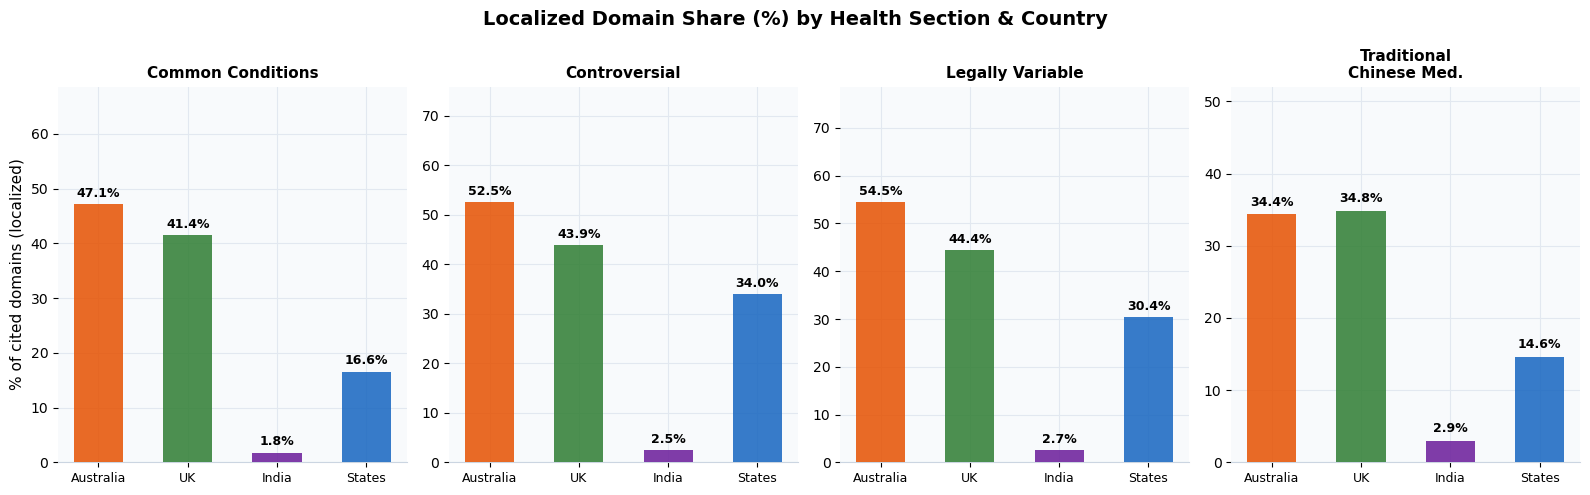

In [7]:
SECTION_LABELS = {
    "common_conditions": "Common Conditions",
    "controversial":     "Controversial",
    "legally_variable":  "Legally Variable",
    "tcm":               "Traditional\nChinese Med.",
}

sec_data = (
    flat[flat["section"].isin(SECTION_LABELS)]
    .groupby(["country", "section", "localized"])
    .size()
    .rename("count")
    .reset_index()
)
sec_data["pct"] = sec_data.groupby(["country", "section"])["count"].transform(
    lambda x: x / x.sum() * 100
)
sec_loc = sec_data[sec_data["localized"]].copy()
sec_loc["section_label"] = sec_loc["section"].map(SECTION_LABELS)

sections_ordered = ["common_conditions", "controversial", "legally_variable", "tcm"]
sec_labels_ordered = [SECTION_LABELS[s] for s in sections_ordered]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.suptitle("Localized Domain Share (%) by Health Section & Country", fontsize=14, fontweight="bold")

for ax, (sec_key, sec_label) in zip(axes, zip(sections_ordered, sec_labels_ordered)):
    vals, cols, ctry_labels = [], [], []
    for country in COUNTRY_ORDER:
        row = sec_loc[(sec_loc["country"] == country) & (sec_loc["section"] == sec_key)]
        val = row["pct"].values[0] if len(row) else 0.0
        vals.append(val)
        cols.append(COUNTRY_COLORS[country])
        ctry_labels.append(country.replace("United ", "").replace("Kingdom", "UK"))

    bars = ax.bar(ctry_labels, vals, color=cols, alpha=0.85, zorder=3, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_title(sec_label, fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.35 + 5)
    ax.set_ylabel("% of cited domains (localized)" if ax == axes[0] else "")
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(axis="y", color="#e2e8f0")
    ax.set_axisbelow(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color("#cbd5e1")

plt.tight_layout()
plt.savefig("localized_by_section.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Stacked Share per Query: Distribution of Localization Across All Queries

Each bar below represents one query. Queries are sorted by localized domain share (high → low). This shows whether localization is consistent across queries or driven by a few outliers.

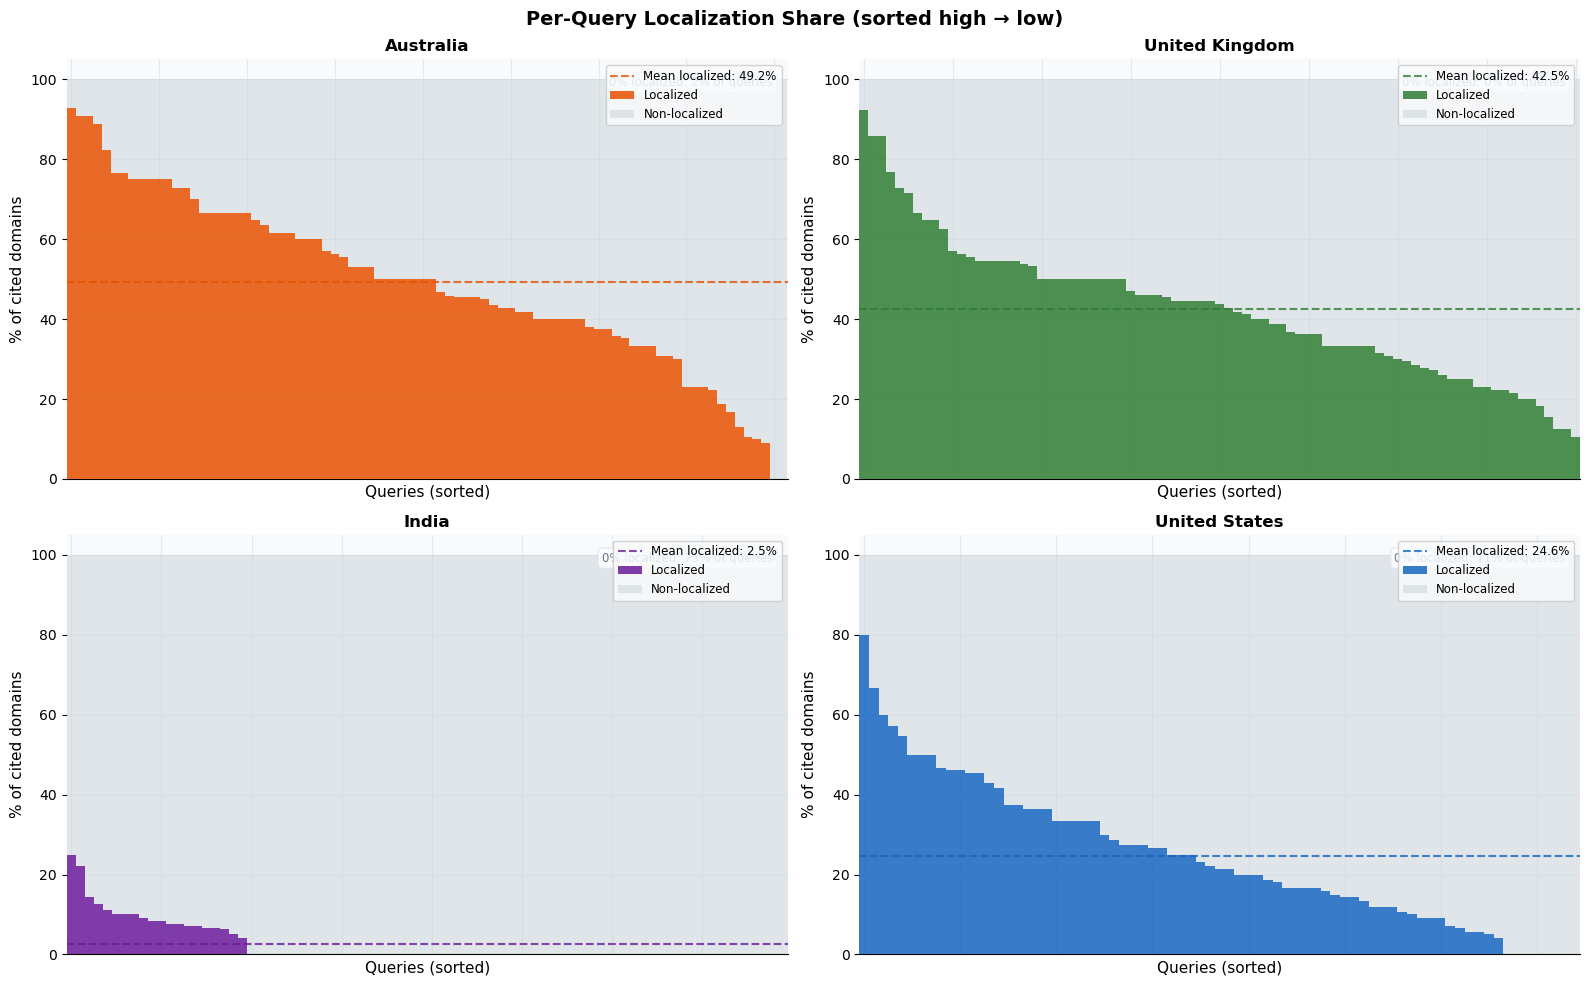

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Per-Query Localization Share (sorted high → low)", fontsize=14, fontweight="bold")

for ax, country in zip(axes.flat, COUNTRY_ORDER):
    cdf = df[df["location"] == country].copy()
    cdf = cdf[cdf["domains"].apply(len) > 0].reset_index(drop=True)

    loc_shares = []
    for _, row in cdf.iterrows():
        doms = row["domains"]
        n_loc = sum(is_localized(d, country) for d in doms)
        loc_shares.append(n_loc / len(doms) * 100 if doms else 0)

    loc_arr = np.array(loc_shares)
    nonloc_arr = 100 - loc_arr
    order = np.argsort(loc_arr)[::-1]
    loc_sorted = loc_arr[order]
    nonloc_sorted = nonloc_arr[order]

    x = np.arange(len(loc_sorted))
    color = COUNTRY_COLORS[country]

    ax.bar(x, loc_sorted,   color=color,   alpha=0.85, label="Localized",     zorder=3, width=1.0)
    ax.bar(x, nonloc_sorted, bottom=loc_sorted, color="#cfd8dc", alpha=0.6,
           label="Non-localized", zorder=2, width=1.0)

    mean_loc = loc_arr.mean()
    ax.axhline(mean_loc, color=color, linewidth=1.5, linestyle="--", alpha=0.8,
               label=f"Mean localized: {mean_loc:.1f}%")

    zero_pct = (loc_arr == 0).mean() * 100
    ax.text(0.98, 0.96, f"0% localized: {zero_pct:.0f}% of queries",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color="#64748b",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e2e8f0", alpha=0.9))

    ax.set_title(country, fontsize=12, fontweight="bold")
    ax.set_xlabel("Queries (sorted)")
    ax.set_ylabel("% of cited domains")
    ax.set_ylim(0, 105)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.legend(fontsize=8.5, loc="upper right", framealpha=0.85)
    ax.grid(axis="y", color="#e2e8f0")
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)

plt.tight_layout()
plt.savefig("localized_per_query.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Summary Statistics Table

In [9]:
rows_out = []
for country in COUNTRY_ORDER:
    cdf_flat = flat[flat["country"] == country]
    cdf_raw  = df[df["location"] == country]

    total_cites = len(cdf_flat)
    loc_cites   = cdf_flat["localized"].sum()
    nonloc_cites = total_cites - loc_cites

    # Per-query localization share stats
    per_q = []
    for _, row in cdf_raw.iterrows():
        doms = row["domains"]
        if doms:
            n_loc = sum(is_localized(d, country) for d in doms)
            per_q.append(n_loc / len(doms) * 100)

    per_q = np.array(per_q)
    zero_q = (per_q == 0).sum()
    any_q  = (per_q > 0).sum()

    rows_out.append({
        "Country":                   country,
        "Localization proxy":        str(LOCALIZED_TLDS[country]),
        "Total citations":           total_cites,
        "Localized citations":       int(loc_cites),
        "Non-localized citations":   int(nonloc_cites),
        "Localized %":               f"{loc_cites / total_cites * 100:.1f}%",
        "Mean loc% per query":       f"{per_q.mean():.1f}%",
        "Median loc% per query":     f"{np.median(per_q):.1f}%",
        "Queries with 0% localized": int(zero_q),
        "Queries with ≥1 localized": int(any_q),
    })

summary_df = pd.DataFrame(rows_out).set_index("Country")
summary_df

,Localization proxy,Total citations,Localized citations,Non-localized citations,Localized %,Mean loc% per query,Median loc% per query,Queries with 0% localized,Queries with ≥1 localized
Country,,,,,,,,,
Australia,"('.au',)",1078,520,558,48.2%,49.2%,50.0%,2,80
United Kingdom,"('.uk', '.scot')",1032,426,606,41.3%,42.5%,43.8%,0,81
India,"('.in',)",972,22,950,2.3%,2.5%,0.0%,60,20
United States,"('.gov', '.edu')",998,227,771,22.7%,24.6%,21.4%,8,67


## 7 · Cross-Country Heatmap: Localization Rate by Section × Country

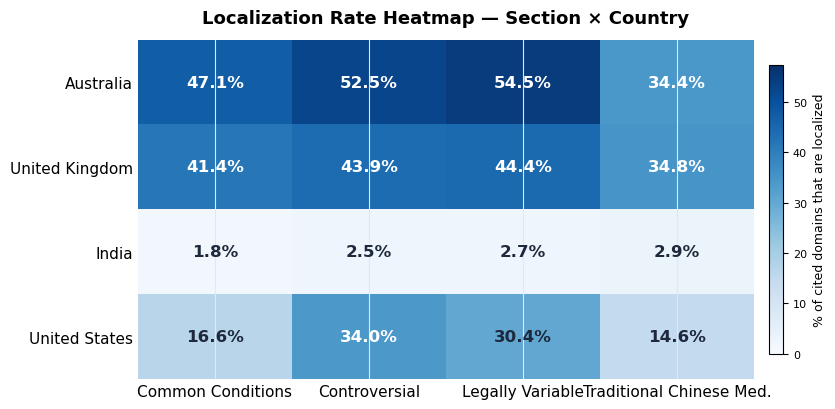

In [10]:
import matplotlib.colors as mcolors

heat_data = []
for country in COUNTRY_ORDER:
    row_vals = []
    for sec in sections_ordered:
        sub = flat[(flat["country"] == country) & (flat["section"] == sec)]
        if len(sub) == 0:
            row_vals.append(np.nan)
        else:
            row_vals.append(sub["localized"].mean() * 100)
    heat_data.append(row_vals)

heat_arr = np.array(heat_data, dtype=float)

fig, ax = plt.subplots(figsize=(9, 4.2))

cmap = plt.cm.Blues
im = ax.imshow(heat_arr, cmap=cmap, aspect="auto", vmin=0, vmax=heat_arr[~np.isnan(heat_arr)].max() * 1.05)

ax.set_xticks(range(len(sections_ordered)))
ax.set_xticklabels([SECTION_LABELS[s].replace("\n", " ") for s in sections_ordered], fontsize=11)
ax.set_yticks(range(len(COUNTRY_ORDER)))
ax.set_yticklabels(COUNTRY_ORDER, fontsize=11)

for i in range(len(COUNTRY_ORDER)):
    for j in range(len(sections_ordered)):
        val = heat_arr[i, j]
        if not np.isnan(val):
            text_color = "white" if val > heat_arr[~np.isnan(heat_arr)].max() * 0.6 else "#1e293b"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                    fontsize=12, fontweight="bold", color=text_color)

cbar = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label("% of cited domains that are localized", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title("Localization Rate Heatmap — Section × Country", fontsize=13, fontweight="bold", pad=12)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.savefig("localized_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 · Key Findings

In [11]:
print("=" * 62)
print("KEY FINDINGS — LOCALIZED DOMAIN ANALYSIS")
print("=" * 62)

for country in COUNTRY_ORDER:
    cdf = flat[flat["country"] == country]
    total = len(cdf)
    loc   = cdf["localized"].sum()
    pct   = loc / total * 100

    # Most cited localized domain
    top_loc = (cdf[cdf["localized"]]["domain"].value_counts().index[0]
               if cdf["localized"].any() else "N/A")
    top_loc_cnt = (cdf[cdf["localized"]]["domain"].value_counts().iloc[0]
                   if cdf["localized"].any() else 0)

    # Section with highest localization
    best_sec, best_sec_pct = None, 0
    for sec in sections_ordered:
        sub = cdf[cdf["section"] == sec]
        if len(sub):
            p = sub["localized"].mean() * 100
            if p > best_sec_pct:
                best_sec_pct = p
                best_sec = sec

    print(f"\n{country}")
    print(f"  Localized share: {pct:.1f}%  ({int(loc):,} / {total:,} citations)")
    print(f"  Top localized domain: {top_loc} ({top_loc_cnt} citations)")
    print(f"  Highest localization section: {SECTION_LABELS.get(best_sec, best_sec)} ({best_sec_pct:.1f}%)")
    print(f"  Localization proxy: {LOCALIZED_TLDS[country]}")

print("\n" + "=" * 62)
print("INDIA NOTE: .in ccTLD is rarely used by major health sites;")
print("  most Indian content uses .com — so localization is")
print("  systematically underestimated for India.")
print("=" * 62)

KEY FINDINGS — LOCALIZED DOMAIN ANALYSIS

Australia
  Localized share: 48.2%  (520 / 1,078 citations)
  Top localized domain: healthdirect.gov.au (79 citations)
  Highest localization section: Legally Variable (54.5%)
  Localization proxy: ('.au',)

United Kingdom
  Localized share: 41.3%  (426 / 1,032 citations)
  Top localized domain: nhs.uk (109 citations)
  Highest localization section: Legally Variable (44.4%)
  Localization proxy: ('.uk', '.scot')

India
  Localized share: 2.3%  (22 / 972 citations)
  Top localized domain: maxhealthcare.in (7 citations)
  Highest localization section: Traditional
Chinese Med. (2.9%)
  Localization proxy: ('.in',)

United States
  Localized share: 22.7%  (227 / 998 citations)
  Top localized domain: cdc.gov (47 citations)
  Highest localization section: Controversial (34.0%)
  Localization proxy: ('.gov', '.edu')

INDIA NOTE: .in ccTLD is rarely used by major health sites;
  most Indian content uses .com — so localization is
  systematically under